# Checkpoint 5 – Análise Estatística e Machine Learning com o Dataset Wines

**Curso:** Tecnólogo em Inteligência Artificial  
**Disciplinas:** Statistical Computing with R & Python e Machine Learning & Modelling  

## Integrantes

- Aline Delphino Chiaramonte — RM569860
- Gabriel Gomes dos Santos — RM573836
- Gustavo Luiz Vilella Santin - RM573213
- Victor Dias Rodrigues Bandeira de Azevedo — RM574108

---

## Objetivo do trabalho

Este trabalho tem como objetivo integrar conceitos de análise estatística e Machine Learning utilizando o dataset **Wines**.

Na primeira etapa será realizada uma análise exploratória e estatística de duas variáveis quantitativas do conjunto de dados: **Alcohol** e **Malic_Acid**. Serão analisadas distribuições de frequência, medidas de tendência central, medidas de dispersão, quartis e probabilidades.

Na segunda etapa será aplicado o algoritmo de aprendizagem não supervisionada **K-Means**, com o objetivo de identificar grupos de vinhos que apresentem características físico-químicas semelhantes.

Para determinar uma quantidade adequada de clusters serão utilizados o **Método Elbow** e o **Silhouette Score**. Posteriormente, os grupos encontrados serão analisados e comparados para identificar as principais características que diferenciam os vinhos de cada cluster.

# 1. Preparação do ambiente

Antes de iniciar a análise dos dados, serão importadas as bibliotecas necessárias para manipulação dos dados, cálculos estatísticos, visualização gráfica, pré-processamento e aplicação do algoritmo K-Means.

In [1]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Estatística
from scipy import stats

# Pré-processamento
from sklearn.preprocessing import StandardScaler

# Machine Learning
from sklearn.cluster import KMeans

# Avaliação dos clusters
from sklearn.metrics import silhouette_score

# Configuração para melhor visualização das tabelas
pd.set_option('display.max_columns', None)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


### Bibliotecas utilizadas

- **Pandas:** utilizada para carregar, organizar, manipular e analisar os dados em estruturas chamadas DataFrames.
- **NumPy:** fornece recursos para cálculos numéricos e operações matemáticas.
- **Matplotlib:** utilizada para construir gráficos e visualizar o comportamento das variáveis.
- **SciPy:** fornece recursos para análises estatísticas e será utilizada para estimar a distribuição de densidade de probabilidade das variáveis.
- **StandardScaler:** utilizado para padronizar as variáveis antes da aplicação do K-Means.
- **KMeans:** implementação do algoritmo K-Means utilizada para realizar o agrupamento dos vinhos.
- **Silhouette Score:** métrica utilizada para avaliar a qualidade da separação dos clusters encontrados pelo K-Means.

# 2. Carregamento do dataset

O conjunto de dados utilizado contém características físico-químicas de diferentes vinhos.

Inicialmente, o arquivo será importado para o ambiente do Google Colab e carregado em um DataFrame do Pandas.

O dataset Wines utilizado é o conjunto indicado no enunciado da avaliação, disponibilizado por meio do Kaggle e GitHub.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving wine-clustering.csv to wine-clustering.csv


In [3]:
df = pd.read_csv('wine-clustering.csv')

# Visualizando as cinco primeiras linhas
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 2.1 Conhecendo o conjunto de dados

Antes de iniciar as análises estatísticas e a modelagem, é necessário compreender a estrutura do dataset.

Serão verificadas:

- quantidade de linhas e colunas;
- nomes das variáveis;
- tipos dos dados;
- existência de valores ausentes;
- existência de registros duplicados.

Essa etapa é importante para identificar possíveis necessidades de tratamento antes das análises posteriores.

In [4]:
print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

print("\nVariáveis disponíveis no dataset:")
for coluna in df.columns:
    print("-", coluna)

Quantidade de linhas: 178
Quantidade de colunas: 13

Variáveis disponíveis no dataset:
- Alcohol
- Malic_Acid
- Ash
- Ash_Alcanity
- Magnesium
- Total_Phenols
- Flavanoids
- Nonflavanoid_Phenols
- Proanthocyanins
- Color_Intensity
- Hue
- OD280
- Proline


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [6]:
print("Valores ausentes por variável:")
print(df.isnull().sum())

print("\nTotal de valores ausentes:", df.isnull().sum().sum())

Valores ausentes por variável:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Total de valores ausentes: 0


In [7]:
duplicados = df.duplicated().sum()

print("Quantidade de registros duplicados:", duplicados)

Quantidade de registros duplicados: 0


### Análise inicial dos dados

O dataset possui **178 registros e 13 variáveis quantitativas**, representando diferentes propriedades físico-químicas dos vinhos.

A inspeção dos tipos de dados mostrou que todas as variáveis são numéricas, sendo compostas por valores inteiros e valores de ponto flutuante.

Também foi realizada uma verificação de valores ausentes. O conjunto de dados não apresenta dados nulos, portanto não foi necessária a aplicação de técnicas de imputação ou exclusão de registros nesta etapa.

A verificação inicial é fundamental para assegurar a qualidade dos dados antes da realização da análise estatística e da aplicação do algoritmo de agrupamento.

Também não foram identificados registros duplicados no conjunto de dados.

## 2.2 Estatísticas gerais do dataset

Será utilizada a função `describe()` para obter uma visão inicial das principais estatísticas descritivas das variáveis.

A tabela apresenta, para cada variável:

- número de observações;
- média;
- desvio-padrão;
- valor mínimo;
- primeiro quartil (25%);
- mediana (50%);
- terceiro quartil (75%);
- valor máximo.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Ash_Alcanity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_Intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


# PARTE 1 – Statistical Computing with R & Python

## 3. Seleção das variáveis quantitativas

Para a análise estatística foram selecionadas as seguintes variáveis:

### Alcohol
Representa o teor alcoólico dos vinhos presentes no conjunto de dados.

### Malic_Acid
Representa a concentração de ácido málico presente nos vinhos.

As duas variáveis foram escolhidas por representarem características relevantes para a diferenciação dos vinhos e por permitirem comparar comportamentos distintos em relação à tendência central e à dispersão dos dados.

Para cada variável serão realizadas:

1. distribuição de frequências e representação gráfica;
2. análise das medidas de tendência central;
3. análise das medidas de dispersão;
4. cálculo dos quartis;
5. análise probabilística.

# 4. Análise Estatística da Variável Alcohol

A primeira variável selecionada para análise é `Alcohol`, que representa o teor alcoólico dos vinhos presentes no conjunto de dados.

Inicialmente será construída uma tabela de distribuição de frequências. Para definir a quantidade de classes será utilizada a Regra de Sturges, que considera o número de observações do conjunto de dados.

In [9]:
# Quantidade total de observações do dataset
n = len(df)

# Aplicação da Regra de Sturges para estimar uma quantidade
# adequada de classes para a distribuição de frequências
k_alcohol = int(np.ceil(1 + 3.322 * np.log10(n)))

In [10]:
# Divide os valores de Alcohol em intervalos de classe
# utilizando a quantidade de classes definida pela Regra de Sturges
classes_alcohol = pd.cut(
    df['Alcohol'],
    bins=k_alcohol,
    include_lowest=True
)

# Frequência absoluta: quantidade de vinhos presente em cada intervalo
freq_abs_alcohol = classes_alcohol.value_counts(sort=False)

# Frequência relativa: proporção de observações de cada intervalo
# em relação ao total de registros
freq_rel_alcohol = freq_abs_alcohol / len(df)

# Frequência percentual: converte a frequência relativa para porcentagem
freq_percent_alcohol = freq_rel_alcohol * 100

# Frequência acumulada: soma progressivamente as frequências das classes
freq_acum_alcohol = freq_abs_alcohol.cumsum()

# Organiza as medidas calculadas em uma tabela de distribuição de frequências
tabela_freq_alcohol = pd.DataFrame({
    'Intervalo': freq_abs_alcohol.index.astype(str),
    'Frequência Absoluta': freq_abs_alcohol.values,
    'Frequência Relativa': freq_rel_alcohol.values,
    'Percentual (%)': freq_percent_alcohol.values,
    'Frequência Acumulada': freq_acum_alcohol.values
})

# O arredondamento é utilizado apenas para facilitar a apresentação dos resultados
tabela_freq_alcohol.round({
    'Frequência Relativa': 4,
    'Percentual (%)': 2
})

,Intervalo,Frequência Absoluta,Frequência Relativa,Percentual (%),Frequência Acumulada
0,"(11.025, 11.452]",3,0.0169,1.69,3
1,"(11.452, 11.874]",15,0.0843,8.43,18
2,"(11.874, 12.297]",23,0.1292,12.92,41
3,"(12.297, 12.719]",28,0.1573,15.73,69
4,"(12.719, 13.141]",28,0.1573,15.73,97
5,"(13.141, 13.563]",30,0.1685,16.85,127
6,"(13.563, 13.986]",29,0.1629,16.29,156
7,"(13.986, 14.408]",20,0.1124,11.24,176
8,"(14.408, 14.83]",2,0.0112,1.12,178


### Interpretação da distribuição de frequências

A distribuição de frequências permite observar como os valores de teor alcoólico estão distribuídos entre os vinhos analisados.

Os dados apresentam maior concentração nas classes intermediárias, especialmente próximas de 13% de álcool. Há uma quantidade menor de vinhos nos extremos da distribuição, tanto com teor alcoólico muito baixo quanto muito elevado.

Esse comportamento sugere que grande parte dos vinhos do conjunto possui teor alcoólico próximo da região central da distribuição.

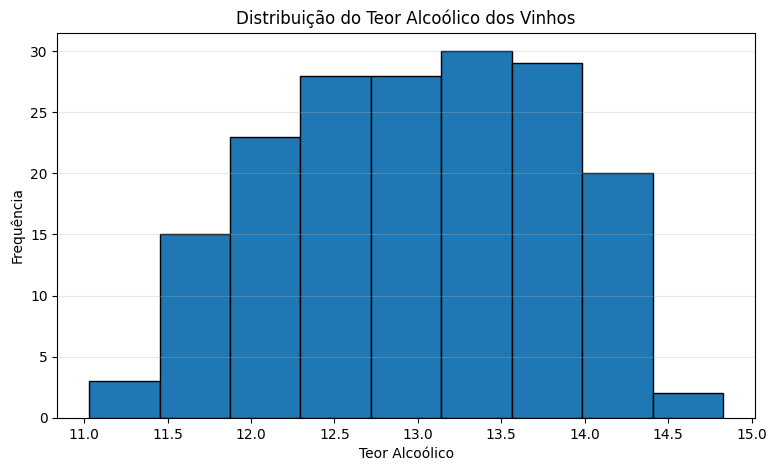

In [11]:
# Constrói o histograma para visualizar como os valores
# de teor alcoólico estão distribuídos no dataset
plt.figure(figsize=(9, 5))

# Utiliza a mesma quantidade de classes definida pela Regra de Sturges
plt.hist(
    df['Alcohol'],
    bins=k_alcohol,
    edgecolor='black'
)

plt.title('Distribuição do Teor Alcoólico dos Vinhos')
plt.xlabel('Teor Alcoólico')
plt.ylabel('Frequência')

plt.grid(axis='y', alpha=0.3)

plt.show()

## 4.1 Medidas de Tendência Central – Alcohol

As medidas de tendência central ajudam a identificar valores representativos do conjunto de dados.

Serão calculadas:

- **Média:** valor médio do teor alcoólico;
- **Mediana:** valor que divide os dados ordenados em duas partes iguais;
- **Moda:** valor ou valores que aparecem com maior frequência.

In [12]:
# Cálculo das medidas de tendência central da variável Alcohol

# Média: representa o valor médio do teor alcoólico
media_alcohol = df['Alcohol'].mean()

# Mediana: representa o valor central após ordenar as observações
mediana_alcohol = df['Alcohol'].median()

# Moda: retorna o valor ou valores com maior frequência no conjunto
moda_alcohol = df['Alcohol'].mode()

print(f"Média: {media_alcohol:.4f}")
print(f"Mediana: {mediana_alcohol:.4f}")
print("Moda:", moda_alcohol.tolist())

Média: 13.0006
Mediana: 13.0500
Moda: [12.37, 13.05]


### Interpretação das medidas de tendência central

O teor alcoólico médio dos vinhos é de aproximadamente **13,00**, enquanto a mediana é aproximadamente **13,05**.

A proximidade entre média e mediana indica que o centro da distribuição está localizado em torno de 13% de álcool e não apresenta grande deslocamento entre essas duas medidas.

A variável apresenta duas modas, aproximadamente **12,37** e **13,05**, indicando que esses valores possuem a maior frequência individual dentro do conjunto de dados.

## 4.2 Medidas de Dispersão – Alcohol

As medidas de dispersão mostram o quanto os valores variam em torno da tendência central.

Serão calculadas:

- valor mínimo;
- valor máximo;
- amplitude;
- variância;
- desvio-padrão;
- coeficiente de variação.

In [13]:
# Identifica os valores mínimo e máximo observados em Alcohol
min_alcohol = df['Alcohol'].min()
max_alcohol = df['Alcohol'].max()

# Amplitude: diferença entre o maior e o menor valor observado
amplitude_alcohol = max_alcohol - min_alcohol

# Variância: mede a dispersão quadrática dos valores em relação à média
variancia_alcohol = df['Alcohol'].var()

# Desvio-padrão: expressa a dispersão na mesma unidade da variável original
desvio_alcohol = df['Alcohol'].std()

# Coeficiente de variação: mede a dispersão proporcionalmente à média
# e permite comparar a variabilidade relativa entre diferentes variáveis
cv_alcohol = (desvio_alcohol / media_alcohol) * 100

print(f"Mínimo: {min_alcohol:.2f}")
print(f"Máximo: {max_alcohol:.2f}")
print(f"Amplitude: {amplitude_alcohol:.2f}")
print(f"Variância: {variancia_alcohol:.4f}")
print(f"Desvio-padrão: {desvio_alcohol:.4f}")
print(f"Coeficiente de variação: {cv_alcohol:.2f}%")

Mínimo: 11.03
Máximo: 14.83
Amplitude: 3.80
Variância: 0.6591
Desvio-padrão: 0.8118
Coeficiente de variação: 6.24%


### Interpretação das medidas de dispersão

Os valores de teor alcoólico variam entre aproximadamente **11,03 e 14,83**, apresentando uma amplitude de **3,80**.

O desvio-padrão é de aproximadamente **0,81**, indicando que os valores geralmente apresentam uma variação relativamente pequena em torno da média de 13,00.

O coeficiente de variação é de aproximadamente **6,24%**, mostrando uma baixa dispersão relativa dos valores de teor alcoólico. Dessa forma, os vinhos apresentam teor alcoólico relativamente homogêneo quando comparados à média da variável.

## 4.3 Medidas Separatrizes – Quartis de Alcohol

Os quartis dividem os dados ordenados em quatro partes.

- **Q1:** 25% dos valores estão abaixo deste ponto;
- **Q2:** corresponde à mediana;
- **Q3:** 75% dos valores estão abaixo deste ponto.

In [14]:
# Cálculo das medidas separatrizes da variável Alcohol

# Q1: aproximadamente 25% das observações ficam abaixo deste valor
q1_alcohol = df['Alcohol'].quantile(0.25)

# Q2: corresponde à mediana da distribuição
q2_alcohol = df['Alcohol'].quantile(0.50)

# Q3: aproximadamente 75% das observações ficam abaixo deste valor
q3_alcohol = df['Alcohol'].quantile(0.75)

# IQR: amplitude dos 50% centrais da distribuição
iqr_alcohol = q3_alcohol - q1_alcohol

print(f"Q1: {q1_alcohol:.4f}")
print(f"Q2 - Mediana: {q2_alcohol:.4f}")
print(f"Q3: {q3_alcohol:.4f}")
print(f"Intervalo Interquartil (IQR): {iqr_alcohol:.4f}")

Q1: 12.3625
Q2 - Mediana: 13.0500
Q3: 13.6775
Intervalo Interquartil (IQR): 1.3150


### Interpretação dos quartis

O primeiro quartil (Q1) é aproximadamente **12,36**, indicando que 25% dos vinhos apresentam teor alcoólico igual ou inferior a esse valor.

A mediana (Q2) é aproximadamente **13,05**, indicando que metade dos vinhos possui teor alcoólico abaixo desse valor e metade acima.

O terceiro quartil (Q3) é aproximadamente **13,68**, mostrando que cerca de 75% dos vinhos possuem teor alcoólico até esse valor.

Assim, os 50% centrais das observações estão aproximadamente entre **12,36 e 13,68**.

## 4.4 Análise Probabilística – Alcohol

Para os cálculos probabilísticos serão utilizadas probabilidades empíricas, ou seja, estimadas a partir da proporção de observações do próprio conjunto de dados.

Serão analisados dois eventos:

1. probabilidade de selecionar aleatoriamente um vinho com teor alcoólico superior a 13;
2. probabilidade de selecionar um vinho com teor alcoólico entre 12 e 13.

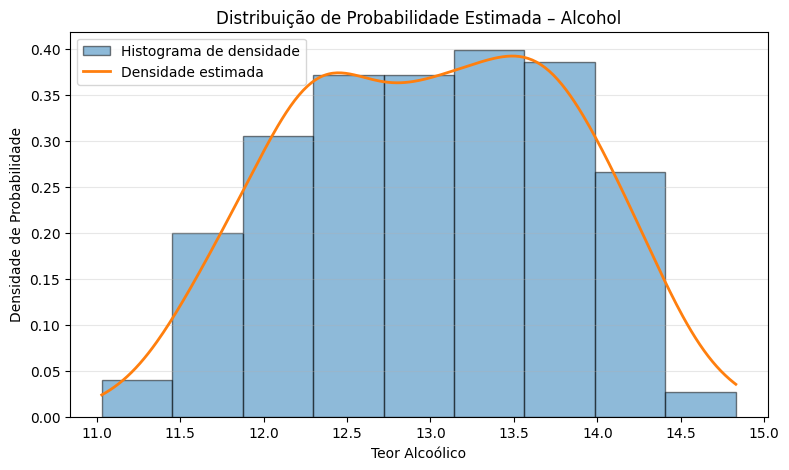

In [15]:
# Cria uma sequência contínua de valores cobrindo todo o intervalo
# observado para Alcohol, usada para desenhar a curva de densidade
valores_alcohol = np.linspace(
    df['Alcohol'].min(),
    df['Alcohol'].max(),
    300
)

# Estima a função de densidade de probabilidade a partir dos dados
# utilizando Kernel Density Estimation (KDE)
kde_alcohol = stats.gaussian_kde(df['Alcohol'])

plt.figure(figsize=(9, 5))

# density=True transforma o histograma em densidade, permitindo
# compará-lo diretamente com a curva de probabilidade estimada
plt.hist(
    df['Alcohol'],
    bins=k_alcohol,
    density=True,
    edgecolor='black',
    alpha=0.5,
    label='Histograma de densidade'
)

# Plota a curva de densidade estimada pelo KDE
plt.plot(
    valores_alcohol,
    kde_alcohol(valores_alcohol),
    linewidth=2,
    label='Densidade estimada'
)

plt.title('Distribuição de Probabilidade Estimada – Alcohol')
plt.xlabel('Teor Alcoólico')
plt.ylabel('Densidade de Probabilidade')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

### Distribuição de probabilidade de Alcohol

O gráfico de densidade permite visualizar a distribuição de probabilidade estimada da variável Alcohol.

Observa-se maior concentração de probabilidade em torno dos valores centrais da distribuição, próximos de 13, enquanto valores localizados nos extremos apresentam menor densidade.

A distribuição apresenta comportamento relativamente concentrado, resultado consistente com o baixo coeficiente de variação observado anteriormente.

In [16]:
# Define o evento: selecionar um vinho com teor alcoólico superior a 13
# e conta quantos registros satisfazem essa condição
quantidade_maior_13 = (df['Alcohol'] > 13).sum()

# Probabilidade empírica = número de casos favoráveis / total de observações
prob_maior_13 = quantidade_maior_13 / len(df)

print("Quantidade de vinhos com Alcohol > 13:", quantidade_maior_13)
print(f"Probabilidade: {prob_maior_13:.4f}")
print(f"Probabilidade percentual: {prob_maior_13 * 100:.2f}%")

Quantidade de vinhos com Alcohol > 13: 92
Probabilidade: 0.5169
Probabilidade percentual: 51.69%


In [17]:
# Define o evento: teor alcoólico entre 12 e 13, incluindo os limites
quantidade_12_13 = (
    (df['Alcohol'] >= 12) &
    (df['Alcohol'] <= 13)
).sum()

# Calcula a probabilidade empírica do evento no conjunto analisado
prob_12_13 = quantidade_12_13 / len(df)

print("Quantidade de vinhos entre 12 e 13:", quantidade_12_13)
print(f"Probabilidade: {prob_12_13:.4f}")
print(f"Probabilidade percentual: {prob_12_13 * 100:.2f}%")

Quantidade de vinhos entre 12 e 13: 67
Probabilidade: 0.3764
Probabilidade percentual: 37.64%


### Interpretação probabilística de Alcohol

Considerando a distribuição empírica dos dados, a probabilidade de selecionar aleatoriamente um vinho com teor alcoólico superior a 13 é de aproximadamente **51,69%**.

Isso significa que pouco mais da metade dos vinhos analisados apresenta teor alcoólico acima de 13.

Já a probabilidade de selecionar um vinho com teor alcoólico entre 12 e 13 é de aproximadamente **37,64%**, indicando que uma parcela relevante do conjunto está concentrada nesse intervalo.

# 5. Análise Estatística da Variável Malic_Acid

A segunda variável selecionada é `Malic_Acid`, que representa a concentração de ácido málico presente nos vinhos.

Serão utilizadas as mesmas etapas aplicadas à variável Alcohol, permitindo posteriormente comparar o comportamento estatístico das duas características.

In [18]:
# Aplica a mesma Regra de Sturges à variável Malic_Acid.
# Como o número de observações continua sendo 178, a quantidade
# estimada de classes também será a mesma utilizada em Alcohol.
k_malic = int(np.ceil(1 + 3.322 * np.log10(len(df))))

print("Número de classes pela Regra de Sturges:", k_malic)

Número de classes pela Regra de Sturges: 9


In [19]:
# Divide os valores de Malic_Acid em intervalos de classe
classes_malic = pd.cut(
    df['Malic_Acid'],
    bins=k_malic,
    include_lowest=True
)

# Frequência absoluta: quantidade de observações em cada intervalo
freq_abs_malic = classes_malic.value_counts(sort=False)

# Frequência relativa: proporção de observações de cada intervalo
freq_rel_malic = freq_abs_malic / len(df)

# Converte a frequência relativa para percentual
freq_percent_malic = freq_rel_malic * 100

# Soma progressivamente as frequências das classes
freq_acum_malic = freq_abs_malic.cumsum()

# Organiza os resultados em uma tabela de distribuição de frequências
tabela_freq_malic = pd.DataFrame({
    'Intervalo': freq_abs_malic.index.astype(str),
    'Frequência Absoluta': freq_abs_malic.values,
    'Frequência Relativa': freq_rel_malic.values,
    'Percentual (%)': freq_percent_malic.values,
    'Frequência Acumulada': freq_acum_malic.values
})

# O arredondamento é utilizado apenas para melhorar a apresentação
tabela_freq_malic.round({
    'Frequência Relativa': 4,
    'Percentual (%)': 2
})

,Intervalo,Frequência Absoluta,Frequência Relativa,Percentual (%),Frequência Acumulada
0,"(0.734, 1.302]",21,0.1180,11.80,21
1,"(1.302, 1.864]",68,0.3820,38.20,89
2,"(1.864, 2.427]",25,0.1404,14.04,114
3,"(2.427, 2.989]",16,0.0899,8.99,130
4,"(2.989, 3.551]",16,0.0899,8.99,146
5,"(3.551, 4.113]",17,0.0955,9.55,163
6,"(4.113, 4.676]",8,0.0449,4.49,171
7,"(4.676, 5.238]",4,0.0225,2.25,175
8,"(5.238, 5.8]",3,0.0169,1.69,178


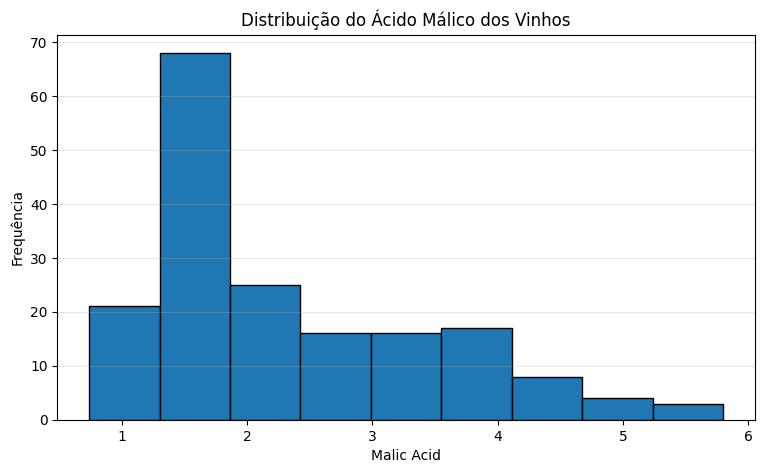

In [20]:
# Constrói o histograma para observar o formato da distribuição
# dos valores de ácido málico
plt.figure(figsize=(9, 5))

plt.hist(
    df['Malic_Acid'],
    bins=k_malic,
    edgecolor='black'
)

plt.title('Distribuição do Ácido Málico dos Vinhos')
plt.xlabel('Malic Acid')
plt.ylabel('Frequência')

plt.grid(axis='y', alpha=0.3)

plt.show()

### Interpretação da distribuição de frequências

A distribuição da variável Malic_Acid apresenta maior concentração nos intervalos de valores mais baixos, especialmente na região próxima de 1,3 a 1,9.

À medida que os valores de ácido málico aumentam, a frequência tende a diminuir, embora existam alguns vinhos com concentrações consideravelmente maiores.

Visualmente, a distribuição apresenta assimetria à direita, indicando a presença de uma cauda formada por valores elevados de ácido málico.

In [21]:
# Cálculo das medidas de tendência central de Malic_Acid

# Média da concentração de ácido málico
media_malic = df['Malic_Acid'].mean()

# Mediana: valor central da distribuição ordenada
mediana_malic = df['Malic_Acid'].median()

# Moda: valor com maior frequência no conjunto
moda_malic = df['Malic_Acid'].mode()

print(f"Média: {media_malic:.4f}")
print(f"Mediana: {mediana_malic:.4f}")
print("Moda:", moda_malic.tolist())

Média: 2.3363
Mediana: 1.8650
Moda: [1.73]


### Interpretação das medidas de tendência central

A média da concentração de ácido málico é aproximadamente **2,34**, enquanto a mediana é aproximadamente **1,87** e a moda é **1,73**.

Nesse caso, a média é superior à mediana e à moda. Esse comportamento é compatível com a assimetria observada no histograma, pois valores elevados de ácido málico aumentam a média e deslocam essa medida para a direita.

In [22]:
# Identifica os valores mínimo e máximo observados em Malic_Acid
min_malic = df['Malic_Acid'].min()
max_malic = df['Malic_Acid'].max()

# Amplitude: diferença entre os valores máximo e mínimo
amplitude_malic = max_malic - min_malic

# Variância e desvio-padrão medem a dispersão em relação à média
variancia_malic = df['Malic_Acid'].var()
desvio_malic = df['Malic_Acid'].std()

# Coeficiente de variação: dispersão percentual em relação à média,
# permitindo comparação com a variável Alcohol
cv_malic = (desvio_malic / media_malic) * 100

print(f"Mínimo: {min_malic:.2f}")
print(f"Máximo: {max_malic:.2f}")
print(f"Amplitude: {amplitude_malic:.2f}")
print(f"Variância: {variancia_malic:.4f}")
print(f"Desvio-padrão: {desvio_malic:.4f}")
print(f"Coeficiente de variação: {cv_malic:.2f}%")

Mínimo: 0.74
Máximo: 5.80
Amplitude: 5.06
Variância: 1.2480
Desvio-padrão: 1.1171
Coeficiente de variação: 47.82%


### Interpretação das medidas de dispersão

A concentração de ácido málico varia entre aproximadamente **0,74 e 5,80**, resultando em uma amplitude de **5,06**.

O desvio-padrão é de aproximadamente **1,12**.

O coeficiente de variação é aproximadamente **47,82%**, indicando uma dispersão relativa elevada.

Comparando com a variável Alcohol, cujo coeficiente de variação foi de aproximadamente 6,24%, é possível observar que os valores de Malic_Acid são consideravelmente mais heterogêneos.

In [23]:
# Cálculo dos quartis da variável Malic_Acid
q1_malic = df['Malic_Acid'].quantile(0.25)  # primeiro quartil
q2_malic = df['Malic_Acid'].quantile(0.50)  # mediana
q3_malic = df['Malic_Acid'].quantile(0.75)  # terceiro quartil

# IQR: amplitude dos 50% centrais da distribuição
iqr_malic = q3_malic - q1_malic

print(f"Q1: {q1_malic:.4f}")
print(f"Q2 - Mediana: {q2_malic:.4f}")
print(f"Q3: {q3_malic:.4f}")
print(f"Intervalo Interquartil: {iqr_malic:.4f}")

Q1: 1.6025
Q2 - Mediana: 1.8650
Q3: 3.0825
Intervalo Interquartil: 1.4800


### Interpretação dos quartis

O primeiro quartil (Q1) é aproximadamente **1,60**, indicando que 25% dos vinhos apresentam concentração de ácido málico igual ou inferior a esse valor.

A mediana é aproximadamente **1,87**, enquanto o terceiro quartil é aproximadamente **3,08**.

Dessa forma, os 50% centrais das observações de Malic_Acid encontram-se aproximadamente entre **1,60 e 3,08**.

## 5.1 Análise Probabilística – Malic_Acid

Novamente serão utilizadas probabilidades empíricas calculadas a partir das observações do conjunto de dados.

Serão analisados:

1. probabilidade de selecionar um vinho com Malic_Acid acima da média;
2. probabilidade de selecionar um vinho com Malic_Acid entre o primeiro e o terceiro quartil.

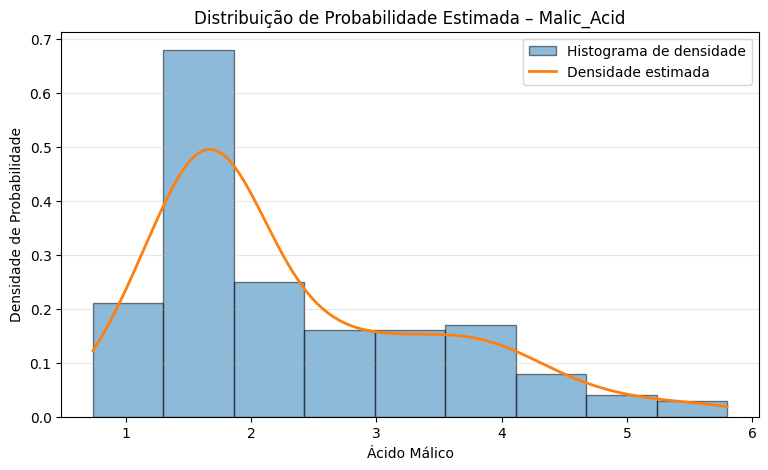

In [24]:
# Cria uma sequência contínua de valores entre o menor e o maior
# resultado observado para Malic_Acid
valores_malic = np.linspace(
    df['Malic_Acid'].min(),
    df['Malic_Acid'].max(),
    300
)

# Estima a função de densidade de probabilidade utilizando KDE
kde_malic = stats.gaussian_kde(df['Malic_Acid'])

plt.figure(figsize=(9, 5))

# O histograma em densidade permite comparar os dados observados
# com a curva de probabilidade estimada
plt.hist(
    df['Malic_Acid'],
    bins=k_malic,
    density=True,
    edgecolor='black',
    alpha=0.5,
    label='Histograma de densidade'
)

# Plota a curva de densidade estimada pelo KDE
plt.plot(
    valores_malic,
    kde_malic(valores_malic),
    linewidth=2,
    label='Densidade estimada'
)

plt.title('Distribuição de Probabilidade Estimada – Malic_Acid')
plt.xlabel('Ácido Málico')
plt.ylabel('Densidade de Probabilidade')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

### Distribuição de probabilidade de Malic_Acid

A distribuição de probabilidade estimada de Malic_Acid apresenta maior concentração nos valores mais baixos e uma cauda que se prolonga em direção aos valores mais elevados.

Esse comportamento reforça a presença de assimetria à direita observada anteriormente.

Diferentemente de Alcohol, a concentração de ácido málico apresenta maior dispersão e menor simetria em torno de sua média.

In [25]:
# Conta quantos vinhos apresentam concentração de ácido málico
# superior à média observada
quantidade_acima_media_malic = (
    df['Malic_Acid'] > media_malic
).sum()

# Calcula a probabilidade empírica desse evento
prob_acima_media_malic = (
    quantidade_acima_media_malic / len(df)
)

print("Quantidade acima da média:", quantidade_acima_media_malic)
print(f"Probabilidade: {prob_acima_media_malic:.4f}")
print(f"Probabilidade percentual: {prob_acima_media_malic * 100:.2f}%")

Quantidade acima da média: 67
Probabilidade: 0.3764
Probabilidade percentual: 37.64%


In [26]:
# Seleciona as observações localizadas entre Q1 e Q3,
# intervalo que representa aproximadamente os 50% centrais dos dados
quantidade_entre_quartis = (
    (df['Malic_Acid'] >= q1_malic) &
    (df['Malic_Acid'] <= q3_malic)
).sum()

# Calcula a probabilidade empírica de uma observação pertencer
# ao intervalo interquartil
prob_entre_quartis = quantidade_entre_quartis / len(df)

print("Quantidade entre Q1 e Q3:", quantidade_entre_quartis)
print(f"Probabilidade: {prob_entre_quartis:.4f}")
print(f"Probabilidade percentual: {prob_entre_quartis * 100:.2f}%")

Quantidade entre Q1 e Q3: 88
Probabilidade: 0.4944
Probabilidade percentual: 49.44%


### Interpretação probabilística de Malic_Acid

A probabilidade empírica de selecionar aleatoriamente um vinho com concentração de ácido málico superior à média é aproximadamente **37,64%**.

Esse resultado também está relacionado à assimetria da distribuição: alguns valores elevados aumentam a média, fazendo com que uma parcela menor dos registros esteja acima dela.

A probabilidade de selecionar um vinho com concentração de ácido málico entre o primeiro e o terceiro quartil é aproximadamente **49,44%**, correspondendo aproximadamente à metade central das observações.

# 6. Comparação entre Alcohol e Malic_Acid

As duas variáveis apresentam comportamentos estatísticos distintos.

A variável **Alcohol** possui média e mediana muito próximas e apresenta baixo coeficiente de variação, indicando maior homogeneidade dos valores e concentração em torno de 13.

Por outro lado, **Malic_Acid** apresenta diferença mais evidente entre média e mediana, além de uma distribuição assimétrica à direita. Seu coeficiente de variação é consideravelmente maior, indicando maior heterogeneidade entre os vinhos.

Portanto, enquanto o teor alcoólico apresenta comportamento relativamente estável dentro do conjunto de dados, a concentração de ácido málico apresenta maior variabilidade.

Essas diferenças também poderão contribuir para a separação dos vinhos durante a etapa de agrupamento utilizando o algoritmo K-Means.

# PARTE 2 – Machine Learning & Modelling

# 7. Introdução ao problema de agrupamento

Nesta etapa será utilizado o algoritmo **K-Means** para identificar grupos de vinhos com características físico-químicas semelhantes.

O K-Means é um algoritmo de **aprendizagem não supervisionada**, pois não utiliza uma variável-alvo previamente conhecida para realizar previsões. Em vez disso, o algoritmo procura padrões de similaridade entre as observações e organiza os dados em grupos chamados **clusters**.

O objetivo é verificar se os 178 vinhos podem ser separados em grupos com perfis distintos a partir das 13 características disponíveis no dataset.

Após o agrupamento, os clusters serão analisados para identificar quais características diferenciam os grupos encontrados.

# 8. Pré-processamento dos dados

Antes da aplicação do K-Means, é necessário preparar os dados utilizados pelo algoritmo.

Foram verificadas anteriormente:

- existência de valores ausentes;
- existência de registros duplicados;
- tipos das variáveis;
- presença de variáveis não numéricas.

O dataset não apresenta valores nulos e todas as 13 variáveis são quantitativas.

Além disso, o arquivo utilizado não possui uma coluna de classe ou variável-alvo. Portanto, todas as 13 características físico-químicas serão utilizadas no processo de agrupamento.

In [27]:
# Cria a matriz de características utilizada pelo K-Means.
# Como o dataset não possui variável-alvo ou coluna de classe,
# todas as 13 características quantitativas serão utilizadas.
X = df.copy()

print("Dimensão da matriz de características:", X.shape)

X.head()

Dimensão da matriz de características: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 8.1 Padronização das variáveis

O algoritmo K-Means utiliza distâncias para determinar quais observações são semelhantes entre si.

Como as variáveis do dataset apresentam escalas muito diferentes, utilizar os valores originais poderia fazer com que variáveis de maior magnitude tivessem influência excessiva no agrupamento.

Por exemplo, enquanto a variável `Hue` apresenta valores próximos de 1, a variável `Proline` pode apresentar valores superiores a 1000.

Por esse motivo, será aplicada a técnica de **padronização com StandardScaler**.

Após a padronização, cada variável passa a possuir aproximadamente:

- média igual a 0;
- desvio-padrão igual a 1.

Dessa forma, as características passam a contribuir de maneira mais equilibrada para o cálculo das distâncias realizado pelo K-Means.

In [28]:
# Cria o objeto responsável pela padronização das variáveis
scaler = StandardScaler()

# Aprende a média e o desvio-padrão de cada variável e transforma
# os dados para uma escala comparável, com média próxima de 0
# e desvio-padrão próximo de 1
X_scaled = scaler.fit_transform(X)

# Reconstrói um DataFrame com os dados padronizados apenas para
# facilitar a visualização e manter os nomes originais das colunas
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [29]:
# Verifica se a padronização funcionou corretamente.
# Esperam-se médias próximas de 0 e desvios-padrão próximos de 1.
verificacao_padronizacao = pd.DataFrame({
    'Média': X_scaled_df.mean(),
    'Desvio_Padrão': X_scaled_df.std(ddof=0)
})

# O arredondamento facilita a conferência dos resultados
verificacao_padronizacao.round(2)

,Média,Desvio_Padrão
Alcohol,-0.0,1.0
Malic_Acid,-0.0,1.0
Ash,-0.0,1.0
Ash_Alcanity,-0.0,1.0
Magnesium,-0.0,1.0
Total_Phenols,0.0,1.0
Flavanoids,-0.0,1.0
Nonflavanoid_Phenols,0.0,1.0
Proanthocyanins,-0.0,1.0
Color_Intensity,0.0,1.0


### Resultado do pré-processamento

Após a padronização, as variáveis passaram a apresentar escalas comparáveis.

Essa transformação é especialmente importante para o K-Means, pois o algoritmo utiliza a distância entre os registros para formar os clusters.

Com os dados preparados, a próxima etapa consiste em determinar quantos grupos devem ser utilizados no modelo.

# 9. Determinação do número de clusters

O algoritmo K-Means exige que o número de clusters seja definido previamente.

Para auxiliar nessa escolha serão utilizados dois métodos:

### Método Elbow

O Método Elbow avalia a **inércia**, que representa a soma das distâncias quadráticas entre cada observação e o centro do cluster ao qual pertence.

À medida que o número de clusters aumenta, a inércia tende a diminuir. O objetivo é procurar um ponto em que adicionar novos clusters deixa de produzir uma redução tão significativa.

### Silhouette Score

O Silhouette Score avalia simultaneamente:

- a proximidade de uma observação com as demais observações do mesmo cluster;
- a separação entre diferentes clusters.

Seu valor varia aproximadamente entre -1 e 1. Valores maiores representam uma estrutura de agrupamento mais bem definida.

In [30]:
# Listas utilizadas para armazenar as métricas calculadas
# para cada quantidade de clusters testada
inercias = []
silhuetas = []

# Avalia soluções contendo de 2 a 10 clusters
valores_k = range(2, 11)

for k in valores_k:

    # Cria um modelo K-Means para cada valor de k
    modelo = KMeans(
        n_clusters=k,
        random_state=42,  # garante reprodutibilidade dos resultados
        n_init=10         # testa diferentes inicializações dos centroides
    )

    # Ajusta o modelo aos dados padronizados e identifica
    # o cluster atribuído a cada observação
    grupos = modelo.fit_predict(X_scaled)

    # Inércia: mede a compactação interna dos clusters.
    # Valores menores indicam observações mais próximas dos centroides.
    inercias.append(modelo.inertia_)

    # Silhouette Score: avalia simultaneamente a coesão interna
    # e a separação entre os diferentes clusters
    silhuetas.append(
        silhouette_score(X_scaled, grupos)
    )

print("Testes concluídos!")

Testes concluídos!


In [31]:
# Organiza os resultados das métricas em uma tabela para facilitar
# a comparação entre os diferentes valores de k testados
resultados_k = pd.DataFrame({
    'Número de Clusters (k)': list(valores_k),
    'Inércia': inercias,
    'Silhouette Score': silhuetas
})

resultados_k.round(4)

,Número de Clusters (k),Inércia,Silhouette Score
0,2,1658.7589,0.2593
1,3,1277.9285,0.2849
2,4,1175.4283,0.2602
3,5,1109.5127,0.2016
4,6,1046.0023,0.2372
5,7,981.5952,0.2036
6,8,935.2012,0.1570
7,9,889.8929,0.1499
8,10,845.8952,0.1436


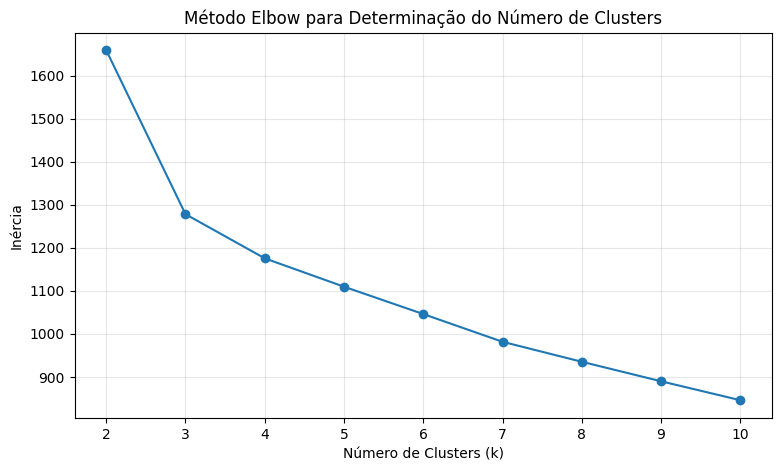

In [32]:
# Método Elbow: relaciona o número de clusters à inércia.
# Procura-se uma região em que aumentar k passe a produzir
# reduções proporcionalmente menores na inércia.
plt.figure(figsize=(9, 5))

plt.plot(
    list(valores_k),
    inercias,
    marker='o'
)

plt.title('Método Elbow para Determinação do Número de Clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')

plt.xticks(list(valores_k))
plt.grid(alpha=0.3)

plt.show()

### Interpretação do Método Elbow

O gráfico mostra uma forte redução da inércia entre **k = 2 e k = 3**.

Após três clusters, a inércia continua diminuindo, como esperado, porém as reduções tornam-se menos expressivas em comparação com a queda inicial.

Dessa forma, o Método Elbow sugere que **k = 3 é um candidato adequado**, embora o ponto de cotovelo não seja extremamente acentuado.

Por esse motivo, a decisão será complementada pela análise do **Silhouette Score**.

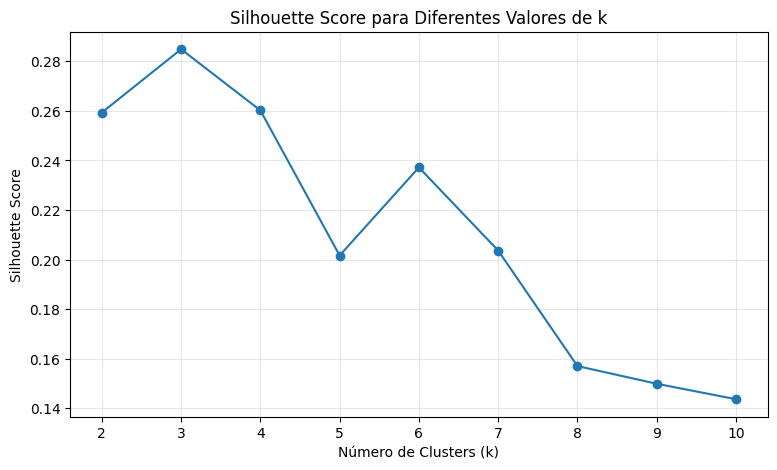

In [33]:
# Compara a qualidade do agrupamento para diferentes valores de k.
# Valores maiores de Silhouette indicam melhor combinação
# entre coesão interna e separação dos clusters.
plt.figure(figsize=(9, 5))

plt.plot(
    list(valores_k),
    silhuetas,
    marker='o'
)

plt.title('Silhouette Score para Diferentes Valores de k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')

plt.xticks(list(valores_k))
plt.grid(alpha=0.3)

plt.show()

In [34]:
# Localiza a posição correspondente ao maior Silhouette Score
melhor_indice = np.argmax(silhuetas)

# Recupera o número de clusters associado ao maior resultado
melhor_k = list(valores_k)[melhor_indice]

# Armazena o valor da melhor métrica obtida
melhor_silhueta = silhuetas[melhor_indice]

print("Melhor número de clusters:", melhor_k)
print(f"Melhor Silhouette Score: {melhor_silhueta:.4f}")

Melhor número de clusters: 3
Melhor Silhouette Score: 0.2849


### Escolha do número de clusters

Os resultados dos métodos Elbow e Silhouette Score foram analisados em conjunto.

No Método Elbow, observa-se uma redução expressiva da inércia entre 2 e 3 clusters. A partir desse ponto, a redução torna-se mais gradual, indicando que adicionar novos clusters gera ganhos progressivamente menores.

O Silhouette Score apresentou seu maior valor para **k = 3**, com aproximadamente **0,2849**.

Dessa forma, considerando conjuntamente os dois critérios, foi adotado **k = 3** para o modelo final.

Embora o valor do Silhouette Score indique que existe alguma sobreposição entre os grupos, k = 3 apresentou o melhor resultado entre as configurações avaliadas.

# 10. Aplicação do K-Means

Após a análise realizada pelos métodos Elbow e Silhouette Score, foi definido o uso de **3 clusters**.

O modelo final será ajustado utilizando os dados previamente padronizados.

In [35]:
# Cria o modelo final com k = 3, escolhido a partir da análise
# conjunta do Método Elbow e do Silhouette Score
kmeans = KMeans(
    n_clusters=3,
    random_state=42,  # garante reprodutibilidade
    n_init=10         # reduz a dependência da inicialização dos centroides
)

# Treina o K-Means utilizando os dados padronizados e atribui
# cada vinho a um dos três clusters
clusters = kmeans.fit_predict(X_scaled)

print("K-Means ajustado com sucesso!")

K-Means ajustado com sucesso!


In [36]:
# Cria uma cópia para preservar o DataFrame original
df_clusters = df.copy()

# Adiciona ao dataset o cluster atribuído pelo K-Means.
# Os valores 0, 1 e 2 são apenas identificadores dos grupos
# e não representam ordem de qualidade ou desempenho.
df_clusters['Cluster'] = clusters

df_clusters.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


In [37]:
# Conta quantas observações foram atribuídas a cada cluster
# para verificar como os 178 vinhos foram distribuídos
quantidade_clusters = (
    df_clusters['Cluster']
    .value_counts()
    .sort_index()
)

quantidade_clusters

,count
Cluster,
0,65
1,51
2,62


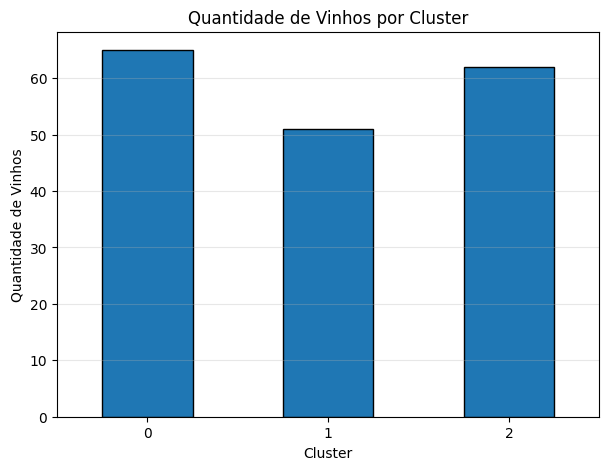

In [38]:
# Representa graficamente a quantidade de vinhos atribuída
# a cada cluster formado pelo modelo
plt.figure(figsize=(7, 5))

quantidade_clusters.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Quantidade de Vinhos por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Quantidade de Vinhos')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

### Distribuição dos vinhos entre os clusters

O modelo separou os 178 vinhos da seguinte forma:

- **Cluster 0:** 65 vinhos;
- **Cluster 1:** 51 vinhos;
- **Cluster 2:** 62 vinhos.

Os grupos apresentam quantidades relativamente próximas de observações, não havendo um único cluster concentrando a grande maioria dos registros.

Os números 0, 1 e 2 são apenas identificadores atribuídos aos clusters e não representam uma ordem de qualidade, superioridade ou desempenho entre os grupos.

# 11. Análise das características dos clusters

Após a formação dos clusters, é necessário compreender quais características físico-químicas diferenciam os grupos.

Para isso, será calculada a média de cada variável dentro de cada cluster.

Essa análise possibilita construir um perfil médio dos vinhos pertencentes a cada grupo.

In [39]:
# Agrupa os vinhos de acordo com o cluster atribuído pelo K-Means
# e calcula a média de cada característica em cada grupo.
# Essas médias permitem identificar e comparar os perfis dos clusters.
perfil_clusters = (
    df_clusters
    .groupby('Cluster')
    .mean()
    .round(3)
)

perfil_clusters

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Cluster,,,,,,,,,,,,,
0,12.251,1.897,2.231,20.063,92.738,2.248,2.050,0.358,1.624,2.973,1.063,2.803,510.169
1,13.134,3.307,2.418,21.241,98.667,1.684,0.819,0.452,1.146,7.235,0.692,1.697,619.059
2,13.677,1.998,2.466,17.463,107.968,2.848,3.003,0.292,1.922,5.454,1.065,3.163,1100.226


In [40]:
# Seleciona as duas variáveis analisadas anteriormente na etapa
# estatística para compará-las diretamente entre os clusters
perfil_clusters[
    ['Alcohol', 'Malic_Acid']
]

,Alcohol,Malic_Acid
Cluster,,
0,12.251,1.897
1,13.134,3.307
2,13.677,1.998


## 11.1 Teor alcoólico e ácido málico

O **Cluster 2** apresenta o maior teor alcoólico médio, com aproximadamente **13,68**, enquanto o Cluster 0 possui o menor valor médio, aproximadamente **12,25**.

Em relação ao ácido málico, o **Cluster 1** apresenta a maior concentração média, aproximadamente **3,31**, valor consideravelmente superior ao observado nos Clusters 0 e 2.

Portanto, entre os grupos encontrados, o Cluster 1 é caracterizado pela maior concentração de ácido málico.

É importante destacar que `Malic_Acid` representa especificamente a concentração de ácido málico e não, isoladamente, uma medida completa da acidez total do vinho.

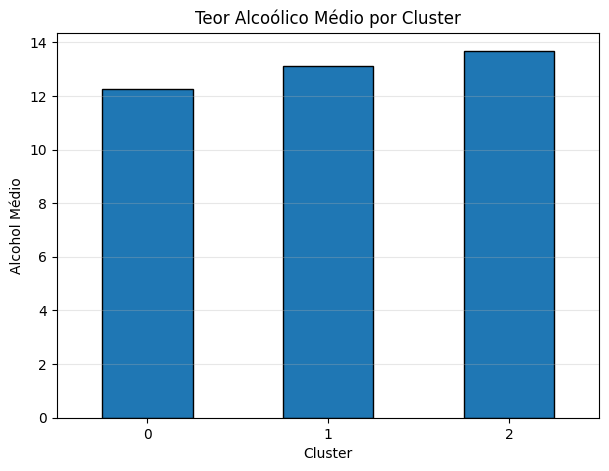

In [41]:
# Compara o teor alcoólico médio entre os três clusters
plt.figure(figsize=(7, 5))

perfil_clusters['Alcohol'].plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Teor Alcoólico Médio por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Alcohol Médio')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

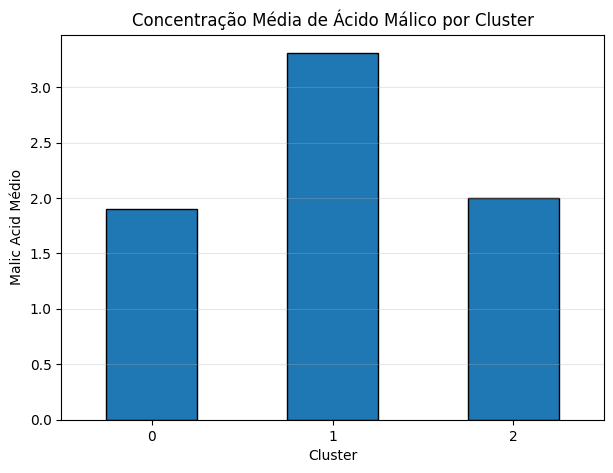

In [42]:
# Compara a concentração média de ácido málico entre os clusters
plt.figure(figsize=(7, 5))

perfil_clusters['Malic_Acid'].plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Concentração Média de Ácido Málico por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Malic Acid Médio')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

## 11.2 Perfil do Cluster 0

O Cluster 0 contém **65 vinhos**.

Entre suas principais características médias estão:

- menor teor alcoólico entre os três grupos, aproximadamente **12,25**;
- baixa concentração de ácido málico, aproximadamente **1,90**;
- menor intensidade de cor, aproximadamente **2,97**;
- menor concentração média de Proline, aproximadamente **510,17**;
- valores intermediários de fenóis e flavonoides quando comparados aos demais clusters.

De maneira geral, esse cluster reúne vinhos que se destacam principalmente pelos menores valores de teor alcoólico, intensidade de cor e Proline em comparação aos demais grupos.

## 11.3 Perfil do Cluster 1

O Cluster 1 contém **51 vinhos**.

Entre suas principais características estão:

- teor alcoólico médio de aproximadamente **13,13**;
- maior concentração média de ácido málico, aproximadamente **3,31**;
- maior intensidade média de cor, aproximadamente **7,24**;
- menores médias de fenóis totais e flavonoides;
- menor média de Hue;
- menor média da variável OD280;
- maior média de fenóis não flavonoides.

Esse grupo apresenta um perfil bastante distinto principalmente pela elevada concentração de ácido málico e intensidade de cor, associadas a menores valores de algumas das variáveis relacionadas aos compostos fenólicos.

## 11.4 Perfil do Cluster 2

O Cluster 2 contém **62 vinhos**.

Entre suas principais características estão:

- maior teor alcoólico médio, aproximadamente **13,68**;
- maior concentração média de magnésio;
- maior média de fenóis totais;
- maior média de flavonoides;
- maior média de proantocianinas;
- maior média de OD280;
- maior concentração média de Proline, aproximadamente **1100,23**.

O Cluster 2 apresenta, portanto, um perfil caracterizado por maior teor alcoólico e valores elevados em diversas características químicas, especialmente fenóis, flavonoides e Proline.

## 11.5 Comparação entre os clusters

Os três clusters apresentam perfis distintos:

### Cluster 0
É caracterizado principalmente por menor teor alcoólico, menor intensidade de cor e menor concentração média de Proline.

### Cluster 1
Destaca-se pela maior concentração de ácido málico e maior intensidade de cor, além de apresentar menores valores médios de fenóis totais, flavonoides, Hue e OD280.

### Cluster 2
Apresenta o maior teor alcoólico médio e maiores valores de diversas características, como magnésio, fenóis totais, flavonoides, proantocianinas, OD280 e Proline.

Esses resultados demonstram que o K-Means conseguiu identificar três perfis distintos dentro do conjunto de vinhos, considerando simultaneamente as 13 características físico-químicas disponíveis.

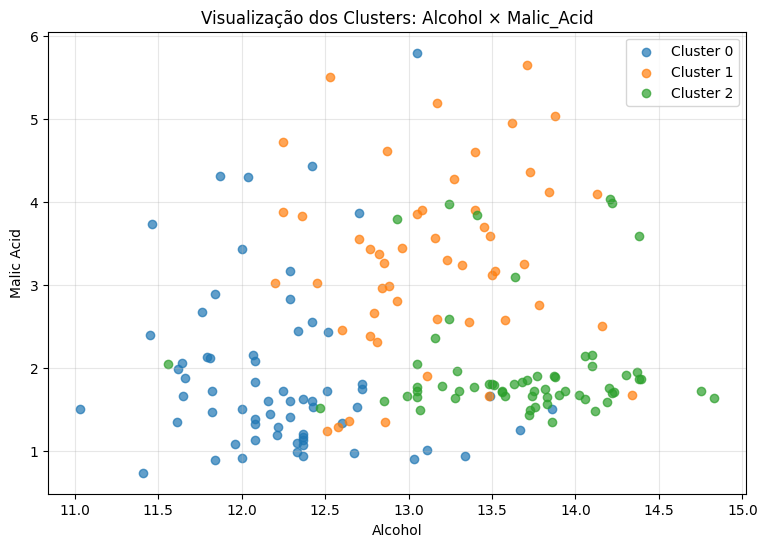

In [43]:
# Visualização bidimensional dos clusters utilizando Alcohol e Malic_Acid.
# Esta figura serve apenas como representação visual: o K-Means foi
# treinado com as 13 características do dataset, e não somente com estas duas.
plt.figure(figsize=(9, 6))

for cluster in sorted(df_clusters['Cluster'].unique()):

    # Seleciona somente os vinhos pertencentes ao cluster atual
    dados_cluster = df_clusters[
        df_clusters['Cluster'] == cluster
    ]

    # Plota cada cluster separadamente para diferenciá-los na legenda
    plt.scatter(
        dados_cluster['Alcohol'],
        dados_cluster['Malic_Acid'],
        label=f'Cluster {cluster}',
        alpha=0.7
    )

plt.title('Visualização dos Clusters: Alcohol × Malic_Acid')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Visualização dos clusters

O gráfico apresenta os vinhos utilizando as variáveis Alcohol e Malic_Acid, com as observações identificadas de acordo com o cluster atribuído pelo K-Means.

É importante destacar que o modelo foi treinado utilizando **13 características**, enquanto o gráfico representa apenas duas delas.

Portanto, a eventual sobreposição visual entre alguns pontos não significa necessariamente que o agrupamento esteja incorreto, pois a separação realizada pelo K-Means considera simultaneamente todas as dimensões utilizadas no treinamento.

# 12. Conclusão da análise de Machine Learning

O algoritmo K-Means foi aplicado com o objetivo de identificar grupos de vinhos que apresentassem características físico-químicas semelhantes.

Antes do treinamento, as 13 variáveis quantitativas foram padronizadas utilizando StandardScaler, evitando que diferenças de escala interferissem excessivamente no cálculo das distâncias.

Para determinar o número de clusters foram utilizados o Método Elbow e o Silhouette Score. A análise conjunta dos dois critérios levou à escolha de **k = 3**, sendo que essa configuração apresentou o maior Silhouette Score entre os valores testados, aproximadamente **0,2849**.

O modelo final dividiu os 178 vinhos em:

- Cluster 0: 65 vinhos;
- Cluster 1: 51 vinhos;
- Cluster 2: 62 vinhos.

A análise das médias mostrou diferenças relevantes entre os grupos. O Cluster 0 apresentou menor teor alcoólico e menor intensidade de cor; o Cluster 1 apresentou maior concentração de ácido málico e maior intensidade de cor; e o Cluster 2 apresentou maior teor alcoólico e maiores valores médios para diversas características, incluindo fenóis, flavonoides e Proline.

Dessa forma, o K-Means permitiu identificar padrões relevantes no conjunto de dados sem utilizar previamente uma variável de classe.

# 13. Conclusão Geral

Este trabalho integrou técnicas de análise estatística e Machine Learning para explorar o dataset Wines.

Na etapa estatística foram analisadas as variáveis Alcohol e Malic_Acid. Os resultados mostraram que Alcohol apresenta menor dispersão relativa e valores mais concentrados em torno da média, enquanto Malic_Acid apresenta maior variabilidade e uma distribuição assimétrica à direita.

Na etapa de Machine Learning, as características dos vinhos foram padronizadas e submetidas ao algoritmo K-Means. Os métodos Elbow e Silhouette Score foram utilizados para auxiliar na escolha do número de clusters, resultando na utilização de três grupos.

A análise posterior mostrou que os clusters possuem características diferentes em relação ao teor alcoólico, ácido málico, intensidade de cor, fenóis, flavonoides, Proline e outras propriedades.

Assim, a análise estatística permitiu compreender individualmente o comportamento de algumas variáveis, enquanto o Machine Learning possibilitou analisar simultaneamente diversas características e identificar padrões de similaridade entre os vinhos.